# RFP: Maze Solvers

## Project Overview
You are invited to submit a proposal that answers the following question:

### What path will your elf take?

*Please submit your proposal by **2/11/25 at 11:59 PM**.*

## Required Proposal Components

### 1. Data Description
In the code cell below, use [Gymnasium](https://gymnasium.farama.org/) to set up a [Frozen Lake maze](https://gymnasium.farama.org/environments/toy_text/frozen_lake/) for your project. When you are done with the set up, describe the reward system you plan on using.

*Note, a level 5 maze is at least 10 x 10 cells large and contains at least five lake cells.*

In [2]:
!pip install gymnasium

Defaulting to user installation because normal site-packages is not writeable


In [6]:
import gymnasium as gym
import pandas as pd
import random
import numpy as np

maze = [
    "SFFFFFFFFF",
    "FFFFFFFFFF",
    "FFFHFFFFFF",
    "FFFFFFFFFF",
    "FFFFHFFFFF",
    "FFFFFFFFFF",
    "FFFFFHHFFF",
    "FFFFFFFFFF",
    "FFFFFFFFHF",
    "FFFFFFFFFG",
]

env = gym.make('FrozenLake-v1', desc=maze, render_mode='ansi', is_slippery=False)
num_states = len(maze) * len(maze[0])
num_actions = 4  # Left: 0, Down: 1, Right: 2, Up: 3
q = {state: [0, 0, 0, 0] for state in range(num_states)}
cell_types = [cell for row in maze for cell in row]

In [11]:
env = gym.make('FrozenLake-v1', desc=maze, render_mode='human', is_slippery=False)
env.reset()
env.render()

In [4]:
env.close()

#### The goal will be +50 score, a hole will be -50, and an empty space is -1.

In [7]:
def getReward(state):
    if cell_types[state] == "G":
        return 100
    elif cell_types[state] == "H":
        return -100
    else:
        return -1

### 2. Training Your Model
In the cell seen below, write the code you need to train a Q-Learning model. Display your final Q-table once you are done training your model.

*Note, level 5 work uses only the standard Python library and Pandas to train your Q-Learning model. A level 4 uses external libraries like Baseline3.*

In [8]:
def updateQTable(q, alpha, gamma, current_state, next_state, action):
    current_q = q[current_state][action]
    reward = getReward(next_state)
    next_max_q = max(q[next_state])
    new_q = (1 - alpha) * current_q + alpha * (reward + gamma * next_max_q)
    q[current_state][action] = new_q

In [9]:
def pos_to_state(row, col):
    return row * 10 + col

def state_to_pos(state):
    return state // 10, state % 10


In [10]:
alpha = 0.2
gamma = 0.8
episodes = 10000

for episode in range(episodes):
    current_state, _ = env.reset()
    terminated = False

    while not terminated:
        action = random.randint(0, 3)
        new_state, reward, terminated, truncated, info = env.step(action)
        updateQTable(q, alpha, gamma, current_state, new_state, action)
        current_state = new_state

df = pd.DataFrame(q).T
df.columns = ["Left", "Down", "Right", "Up"]
print(df.head(10))

       Left       Down     Right        Up
0 -3.109976  -2.637504 -2.637467 -3.109979
1 -3.109980  -2.046874 -2.046828 -2.637471
2 -2.637471  -1.308568 -1.308528 -2.046836
3 -2.046835  -0.385695 -0.385651 -1.308531
4 -1.308554   0.767897  0.767954 -0.385658
5 -0.385670   2.209965  2.209953  0.767906
6  0.767876   4.012574  4.012649  2.209940
7  2.209993   6.265875  6.265941  4.012634
8  4.012637   9.082410  9.082698  6.265997
9  6.265964  12.603672  9.082660  9.082757


### 3. Testing Your Model
In the cell seen below, write the code you need to test your Q-Learning model for **1000 episodes**. It is important to test your model for 1000 episodes so that we are all able to compare our results.

*Note, level 5 testing uses both a success rate and an average steps taken metric to evaluate your model. Level 4 uses one or the other.*

In [16]:
import time

def test_agent(q, env, episodes=10, delay=0.5):
    total_wins = 0
    steps = 0
    for episode in range(episodes):        
        state, _ = env.reset()
        terminated = False

        while not terminated:
            env.render() 
            action = np.argmax(q[state])
            new_state, reward, terminated, truncated, info = env.step(action)
            state = new_state
            steps += 1
            time.sleep(delay)
            print(state)
        if cell_types[state] == "G":
            total_wins += 1
            print("Success")
        else:
            print("Failure")
    
    # Print final results
    print(steps/10)

# Run test
test_agent(q, env)

1
2
3
4
5
15
16
17
27
28
29
39
49
59
69
79
89
99
Success
1
2
3
4
5
15
16
17
27
28
29
39
49
59
69
79
89
99
Success
1
2
3
4
5
15
16
17
27
28
29
39
49
59
69
79
89
99
Success
1
2
3
4
5
15
16
17
27
28
29
39
49
59
69
79
89
99
Success
1
2
3
4
5
15
16
17
27
28
29
39
49
59
69
79
89
99
Success
1
2
3
4
5
15
16
17
27
28
29
39
49
59
69
79
89
99
Success
1
2
3
4
5
15
16
17
27
28
29
39
49
59
69
79
89
99
Success
1
2
3
4
5
15
16
17
27
28
29
39
49
59
69
79
89
99
Success
1
2
3
4
5
15
16
17
27
28
29
39
49
59
69
79
89
99
Success
1
2
3
4
5
15
16
17
27
28
29
39
49
59
69
79
89
99
Success
18.0


### 4. Final Answer
In the first cell below, describe the path your elf takes to get to the gift. *Note, a level 5 answer includes a gif of the path your elf takes in order to reach the gift.*

In the second cell seen below, describe how well your Q-Learning model performed. Make sure that you explicitly name the **learning rate**, **the discount factor**, and the **reward system** that you used when training your final model. *Note, a level 5 description describes the model's performance using two types of quantitative evidence.*

Simply, my elf goes right and down without going backwards or up, thus not wasting any movement. the optimal amount of moves is 18, my elf succeeded 100% of the time and had an average step count of 18, so it is good. The maze was not the most difficult in the world, though.

![example image](https://gymnasium.farama.org/_images/frozen_lake.gif)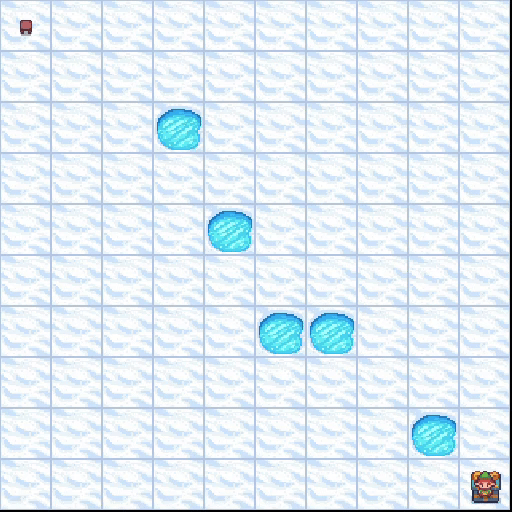

#### Describe the path your elf takes here.

#### Describe how well your Q-Learning model performed here.